# Lab: K-Means Clustering

*In this lab, we will build a **K-Means Clustering** model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
> - **Business Context:** "ShopSmart Mall" is a regional shopping center that has been collecting customer data through its loyalty program, including demographic information and purchasing behaviour metrics. The mall's management currently treats all customers the same, offering identical promotions, communications, and services to everyone. However, they suspect that their customer base is diverse, with different groups having distinct shopping patterns, spending capacities, and preferences. 
> - **Business Problem:** The marketing and operations teams lack a data-driven understanding of their customer base's natural groupings. Without this segmentation, they cannot tailor their strategies effectively. This results in inefficient marketing spend, generic promotional campaigns that don't resonate with specific customer types, and missed opportunities to maximize revenue from high-value segments while appropriately engaging lower-spending customers.
> - **Project Goal:** To discover natural customer segments within the mall's customer base. The ultimate aim is to identify distinct groups based on their characteristics and behaviors, enabling the marketing team to develop targeted strategies, personalized communications, and tailored services for each segment, thereby improving customer satisfaction and maximizing revenue.

---

> ### 📝 2. Analytic Approach Report (Summary)
> - **Problem Type:** *Unsupervised Learning - Clustering*, as the goal is to discover and identify natural groupings in customer data without predefined labels or a target variable.
> - **Model Selection:** We will use *K-Means Clustering* implemented via scikit-learn. K-Means is a centroid-based algorithm that partitions customers into $k$ distinct clusters based on the similarity of their characteristics. It is computationally efficient, easy to interpret, and well-suited for customer segmentation tasks. The resulting cluster assignments can be directly used to define customer personas and develop targeted marketing strategies.
> - **Evaluation Metrics:**
>     - **Elbow Method:** Plot the inertia (within-cluster sum of squares) against different values of $k$. Identify the "elbow" point where the reduction in inertia slows significantly, indicating the optimal number of clusters.
>     - **Silhouette Score:** Measure how similar each customer is to their own cluster relative to other clusters. A higher silhouette score (range -1 to 1) indicates better-defined, more cohesive clusters.
>     - **Visual Inspectation:** Create 2D scatter plots (using PCA for dimensionality reduction if necessary) to visually assess cluster separation and quality.
>     - **Business Interpretation:** Analyze the characteristics of each cluster (mean age, income, spending patterns) to ensure how they form meaningful and actionable customer segments for marketing purposes.  
> - ⚠️ **Caution:** For the scope of this lab, only K-Means will be tested as the clustering algorithm. In a real-world project, it would be prudent to compare multiple clustering algorithms (e.g., Hierarchical Clustering, DBSCAN) to ensure the best approach is selected.

---

> ### 📝 3. Data Requirements Report (Summary)
> - **Data Source:** The `Mall_Customers.csv` dataset from [Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data), which contains customer information collected through the mall's loyalty program.
> - **Features (Customer Characteristics):**
>     - `customer_id`: Unique identifier for each customer
>     - `age`: Age of the customer (in years)
>     - `gender`: Gender of the customer (categorical: Male/Female)
>     - `annual_income`: Annual income of the customer (in thousands of dollars)
>     - `spending_score`: A score assigned based on customer behavior and spending patterns (scale: 1-100)
> - **Target/Outcome:** There is no target variable. The clustering algorithm will discover groupings based on the feature patterns inherent in the customer data.
> - **Granularity & Privacy:** Each row represents an individual customer. The dataset is ananymized through the use of Customer ID, containing no sensitive personally identifiable information (PII) beyond what is necessary for the analysis.

---

## Stage 4: Data Collection
As usual, we start with importing the necessary libraries and configuring them.

In [45]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1. Extraction
Data has been manually downloaded and saved as `../data/raw/Mall_Customers.csv`. Let's verify its contents.

In [46]:
raw_data_dir = Path("../data/raw")
raw_data_path = raw_data_dir / "Mall_Customers.csv"

raw_df = pd.read_csv(raw_data_path)

print(f"Extracted dataset has {raw_df.shape[0]} samples and {raw_df.shape[1]} features, with {raw_df.isnull().values.sum()} missing values out of {raw_df.size}.")

display(raw_df.head())
raw_df.info()


Extracted dataset has 200 samples and 5 features, with 0 missing values out of 1000.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### 4.2. Transformation
Now, we perform the **Transform** step. We apply lightweight corrections to the raw data, such as standardizing column names, and fix any obvious, rule-based data quality issues.

In [47]:
interim_df = raw_df.copy()

# --- Standardization ---
# Rename columns
new_cols = {
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
}
interim_df = interim_df.rename(columns=new_cols)


# ---  Data Quality Validation & Cleaning ---

# Remove fully duplicated rows:
num_duplicates = interim_df.duplicated().sum()

if num_duplicates > 0:
    print(f"⚠️ Found and removed {num_duplicates} fully duplicated rows.")
    interim_df = interim_df.drop_duplicates()
else:
    print("✅ No fully duplicated rows found.")

# Human-Readable summary for manual inspection
interim_df.describe(include='all').T

✅ No fully duplicated rows found.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
annual_income,200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
spending_score,200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


* 📌 Minimum and maximum values for all numerical columns look valid.
* 📌 The `gender` column has 2 categories as expected.

### 4.3. Loading
Now we save the cleaned, transformed DataFrame to the `/data/interim/` directory. This file now becomes the official, clean starting point for all analysis.

In [48]:
# Define and create the interim data directory
interim_data_dir = Path("../data/interim")
interim_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the transformed DataFrame
interim_data_path = interim_data_dir / "mall_customers_interim_v1.parquet"
interim_df.to_parquet(interim_data_path, index=False)

### 4.4. Verification
Finally, let's perform a sanity check. We'll load the interim data we just created and verify its structure and content.

In [49]:
# Load the final interim data and verify its contents
mall_df = pd.read_parquet(interim_data_path)
print(f"Verification successful. The following DataFrame is ready for analysis with {mall_df.shape[0]} samples and {mall_df.shape[1]} features:")
mall_df.sample(5)

Verification successful. The following DataFrame is ready for analysis with 200 samples and 5 features:


,customer_id,gender,age,annual_income,spending_score
161,162,Female,29,79,83
90,91,Female,68,59,55
128,129,Male,59,71,11
53,54,Male,59,43,60
101,102,Female,49,62,48



---

> ### 📝 4. Data Collection Report (Summary)
> * **Collection Process:** The *Mall Customers Dataset* had been already downloaded from [Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data) and was available at `../data/raw/Mall_Customers.csv`.
> * **Initial Verification:** The dataset loads successfully. The number of rows matches the expected count of 200 customers. All five columns (`CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`) are present as expected. There are no missing values in any of the columns, and the data types are appropriate for their respective features.
> * **Data Standardization:** Column names were standardized to snake_case convention (`customer_id`, `gender`, `age`, `annual_income`, `spending_score`) for consistency and ease of use in subsequent analysis.
> * **Data Quality:** No fully duplicated rows were detected. All numerical columns display valid minimum and maximum values, and the `gender` column contains the expected two categories (Male/Female).
> * **Interim Storage:** The cleaned and transformed dataset was saved to `../data/interim/mall_customers_interim_v1.parquet`, establishing a clean baseline for all downstream analysis and modeling stages.

---

## Stage 5: Data Understanding
The goal of this stage is to conduct **Exploratory Data Analysis (EDA)** to develop a deep understanding of the data's content, quality, and structure. Through EDA, we'll discover whether the data is suitable for distance-based clustering and how to prepare it.

### 5.1. Preparation for EDA
Let's perform final preparatory checks and minor adjustments to ensure the DataFrame is perfectly suited for the analysis ahead.

In [50]:
# Create a new DataFrame for EDA
mall_eda = mall_df.copy()

# Check the column_names to see whether we need them all, as well as whether the data types are suitable for EDA
display(mall_eda.dtypes)

# Create a list for numerical features for ease of verification and analysis
numerical_cols = ['age', 'annual_income', 'spending_score']

print("mall_eda DataFrame is ready for EDA with all the needed columns and correct data types.")

customer_id        int64
gender            object
age                int64
annual_income      int64
spending_score     int64
dtype: object

mall_eda DataFrame is ready for EDA with all the needed columns and correct data types.


### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

#### 5.2.1. Numerical Features

In [51]:
# Generate the descriptive statistics for the numerical variables
stats_df = mall_eda[numerical_cols].describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0,0.359563
annual_income,200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0,0.433698
spending_score,200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0,0.514413


* 📌 The customer ages vary between 18 and 70. Average age is 38.85, while the median is 36, indicating a slight right-skew. The coefficient of variation (CV) of 0.36 suggests moderate relative variability.
* 📌 Annual income ranges from 15k to 137k. The mean is 60.56k and the median is 61.50k, implying a near-symmetric distribution. CV of 0.43 shows a higher dispersion than age.
* 📌 Spending scores range from 1 to 99. The mean is 50.20 and the median is 50.00, roughly symmetric. CV of 0.51 is the highest relative variability among the three features.
* 📌 Three features are on different scales, therefore standardization is recommended before K-Means.

#### 5.2.2. Categorical Features
Now let's take a look at the descriptive statistics for our categorical feature, `gender`.

In [52]:
# Calculate gender ratios
gender_ratios = (mall_eda['gender'].value_counts(normalize=True) * 100).round(2)
for gender, ratio in gender_ratios.items():
    print(f"Ratio of {gender} customers: {ratio}%")

Ratio of Female customers: 56.0%
Ratio of Male customers: 44.0%


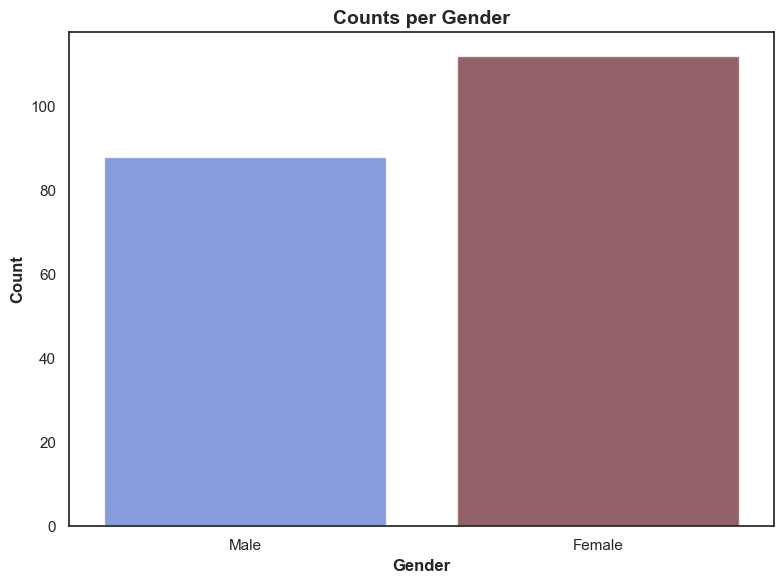

In [55]:
# Visualize the categorical column
plt.figure(figsize=(8, 6))
sns.countplot(mall_eda, x="gender", hue="gender", palette={"Female": "#721420", "Male": "#4169E1"}, legend=False, alpha=0.7)
plt.title("Counts per Gender", fontweight="bold", fontsize=14)
plt.xlabel("Gender", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.tight_layout()
plt.show()

📌 The gender distribution is slightly imbalanced: 56% of customers are female (112 out of 200), while 44% are male (88 out of 200). This modest imbalance is not problematic for clustering but may be worth monitoring during segment analysis.

### 5.3. Univariate Analysis
Now it's time to analyze individual variables to understand their own distributions and characteristics.

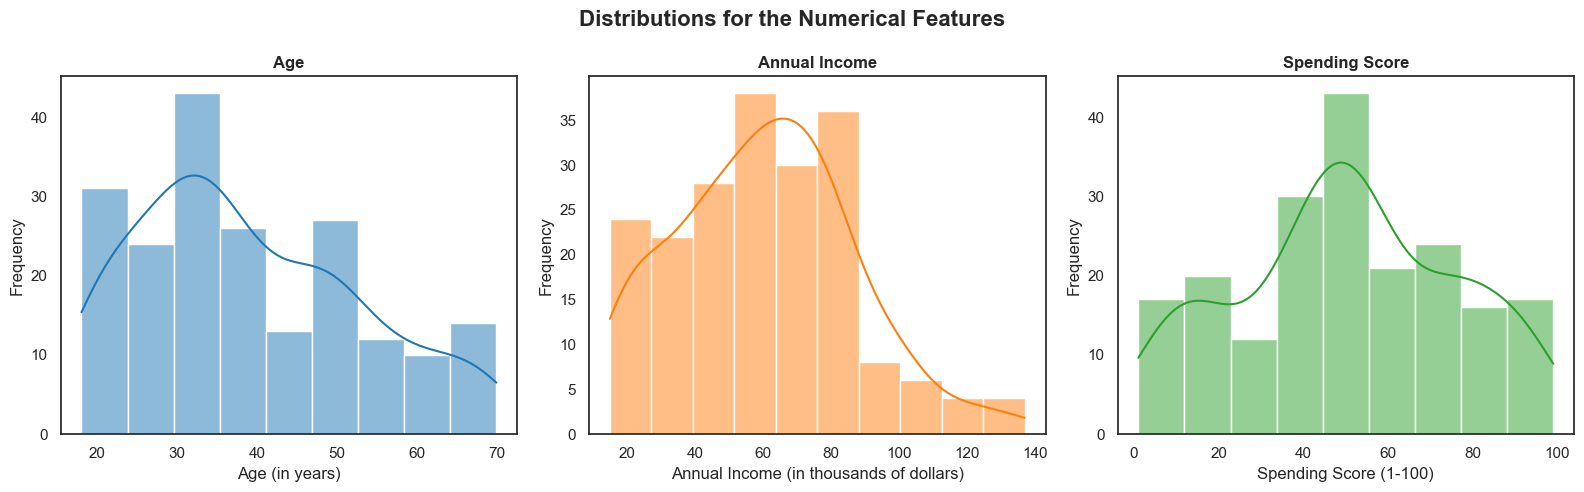

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(16, 5))
fig.suptitle("Distributions for the Numerical Features", fontweight="bold", fontsize=16)

sns.histplot(data=mall_eda, x="age", ax=axs[0], kde=True, color="#1f77b4")
axs[0].set_title("Age", fontweight="bold")
axs[0].set_xlabel("Age (in years)")
axs[0].set_ylabel("Frequency")

sns.histplot(data=mall_eda, x="annual_income", ax=axs[1], kde=True, color="#2ca02c")
axs[1].set_title("Annual Income", fontweight="bold")
axs[1].set_xlabel("Annual Income (in thousands of dollars)")
axs[1].set_ylabel("Frequency")

sns.histplot(data=mall_eda, x="spending_score", ax=axs[2], kde=True, color="#ff7f0e")
axs[2].set_title("Spending Score", fontweight="bold")
axs[2].set_xlabel("Spending Score (1-100)")
axs[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()